In [1]:
import numpy as np
import xarray as xr
import os

from scipy.stats import linregress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import warnings
from mezcal_tools import *

warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Needs to be completed by double checking if impacts sum up to reconstriucted AMOC

In [2]:
scenario = 'piControl'
running_mean_window = 20

lat_min = 0
lat_max = 90

lon_min = -100
lon_max = 15


PATH_SST = '../data/SST/' + scenario + '/'
PATH_AMOC = '../data/AMOC/' + scenario + '/'
PATH_saved_regressions = '../data/SST_AMOC_saved_regressions/'
PATH_saved_cross_regressions = '../data/SST_AMOC_cross_regressions_for_every_model/'

PATH_plots = '/glade/u/home/mmarkina/Plots/MEZCAL/'

model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CESM2-WACCM', 'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1-HR',
               'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5-CanOE', 'CanESM5', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 
               'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 
               'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']


amoc_institution_names = ['CSIRO-ARCCSS', 'CSIRO', 'NCAR', 'NCAR', 'CMCC', 'CMCC', 'CNRM-CERFACS', 
                         'CNRM-CERFACS', 'CNRM-CERFACS', 'CCCma', 'CCCma', 'NOAA-GFDL', 'NOAA-GFDL', 'NASA-GISS', 
                         'MOHC', 'MOHC', 'IPSL', 'MIROC', 'DKRZ', 'MPI-M', 
                         'MRI', 'NCC', 'NCC', 'MOHC']
                         


ens_members_appendices  = ['r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f2', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

## Impact map math

We can write our reconstruction of AMOC $\tilde{x}$ at a single time as a function of contemporaneous SSTs $\mathbf{y}$ using regression weights $\mathbf{e}$ as

\begin{eqnarray}
    \tilde{x} = \mathbf{e}^\top\mathbf{y}.
\end{eqnarray}

Next define the variance of AMOC in terms of the covariance of SSTs:
\begin{eqnarray}
    \sigma^2_x&=\left<\tilde{\mathbf{x}}^\top\tilde{\mathbf{x}}\right>\\
    &=\mathbf{e}^\top\mathbf{C}_{YY}\mathbf{e}.
\end{eqnarray}

We would like to quantify impacts over the spatial domain. To do this, define a symmetric square root of $\mathbf{C}_{YY}$. Note that in practice this does not have to be explicitly computed and stored if we use e.g. the SVD.

\begin{eqnarray}
\mathbf{Y} &= \mathbf{U}\mathbf{\Lambda}\mathbf{V}^\top\\
\mathbf{C}_{YY}^{1/2} &\equiv \frac{1}{\sqrt{N_t-1}} \mathbf{U}\mathbf{\Lambda}^{1/2}\mathbf{U}^\top
\end{eqnarray}

Then substituting $\mathbf{C}_{YY} = \mathbf{C}_{YY}^{1/2}\mathbf{C}_{YY}^{1/2}$ we obtain

\begin{eqnarray}
    \sigma^2_x&=\mathbf{e}^\top\mathbf{C}_{YY}^{1/2}\mathbf{C}_{YY}^{1/2}\mathbf{e}\\
    &=\text{tr}\left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\mathbf{e}^\top\mathbf{C}_{YY}^{1/2}\right)\\
    &=\sum \left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\right)\odot\left(\mathbf{C}_{YY}^{1/2}\mathbf{e}\right)
\end{eqnarray}

so that the impact map is the elementwise product of $\mathbf{C}_{YY}^{1/2}\mathbf{e}$ with itself. We can check this by summing over the impact map, which should recover the AMOC variance. In practice, since AMOC variance can differ among models, it can be useful to normalize by AMOC variance such that the impact map is the variance fraction (and should sum to 1).


In [3]:
def compute_impact_map(f, sst, ny, nx, normalize=True):
    """
    Computes impact map from regression coefficients and SST variability.

    Parameters:
    - f: 1D array of regression coefficients (size = ny * nx)
    - sst: xarray DataArray of SST (time, lat, lon)
    - ny, nx: spatial dimensions
    - normalize: If True, returns fraction of variance (sums to 1)

    Returns:
    - impact_map: xarray DataArray (lat, lon)
    """

    nt, _, _ = sst.shape
    Y = sst.values.reshape([nt, nx * ny]).T
    valid_mask = ~np.isnan(Y).all(axis=1)

    Y = np.where(np.isnan(Y), 0, Y)
    Y -= Y.mean(axis=1, keepdims=True)

    U, s, Vt = np.linalg.svd(Y, full_matrices=False)

    # Project e onto U space, then transform back with sqrt(Λ)
    projection = (U * s**0.5) @ (U.T @ f)
    impact_flat = projection**2 / (nt - 1)

    if normalize:
        impact_flat /= np.sum(impact_flat)

    # Restore to lat/lon and mask
    impact_map = np.full(ny * nx, np.nan)
    impact_map[valid_mask] = impact_flat[valid_mask]
    impact_map = impact_map.reshape(ny, nx)

    return xr.DataArray(
        impact_map,
        coords={"lat": sst["lat"], "lon": sst["lon"]},
        dims=["lat", "lon"],
        attrs={"units": "Sv^2" if not normalize else "fraction"}
    )


# Plotting impact maps

ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


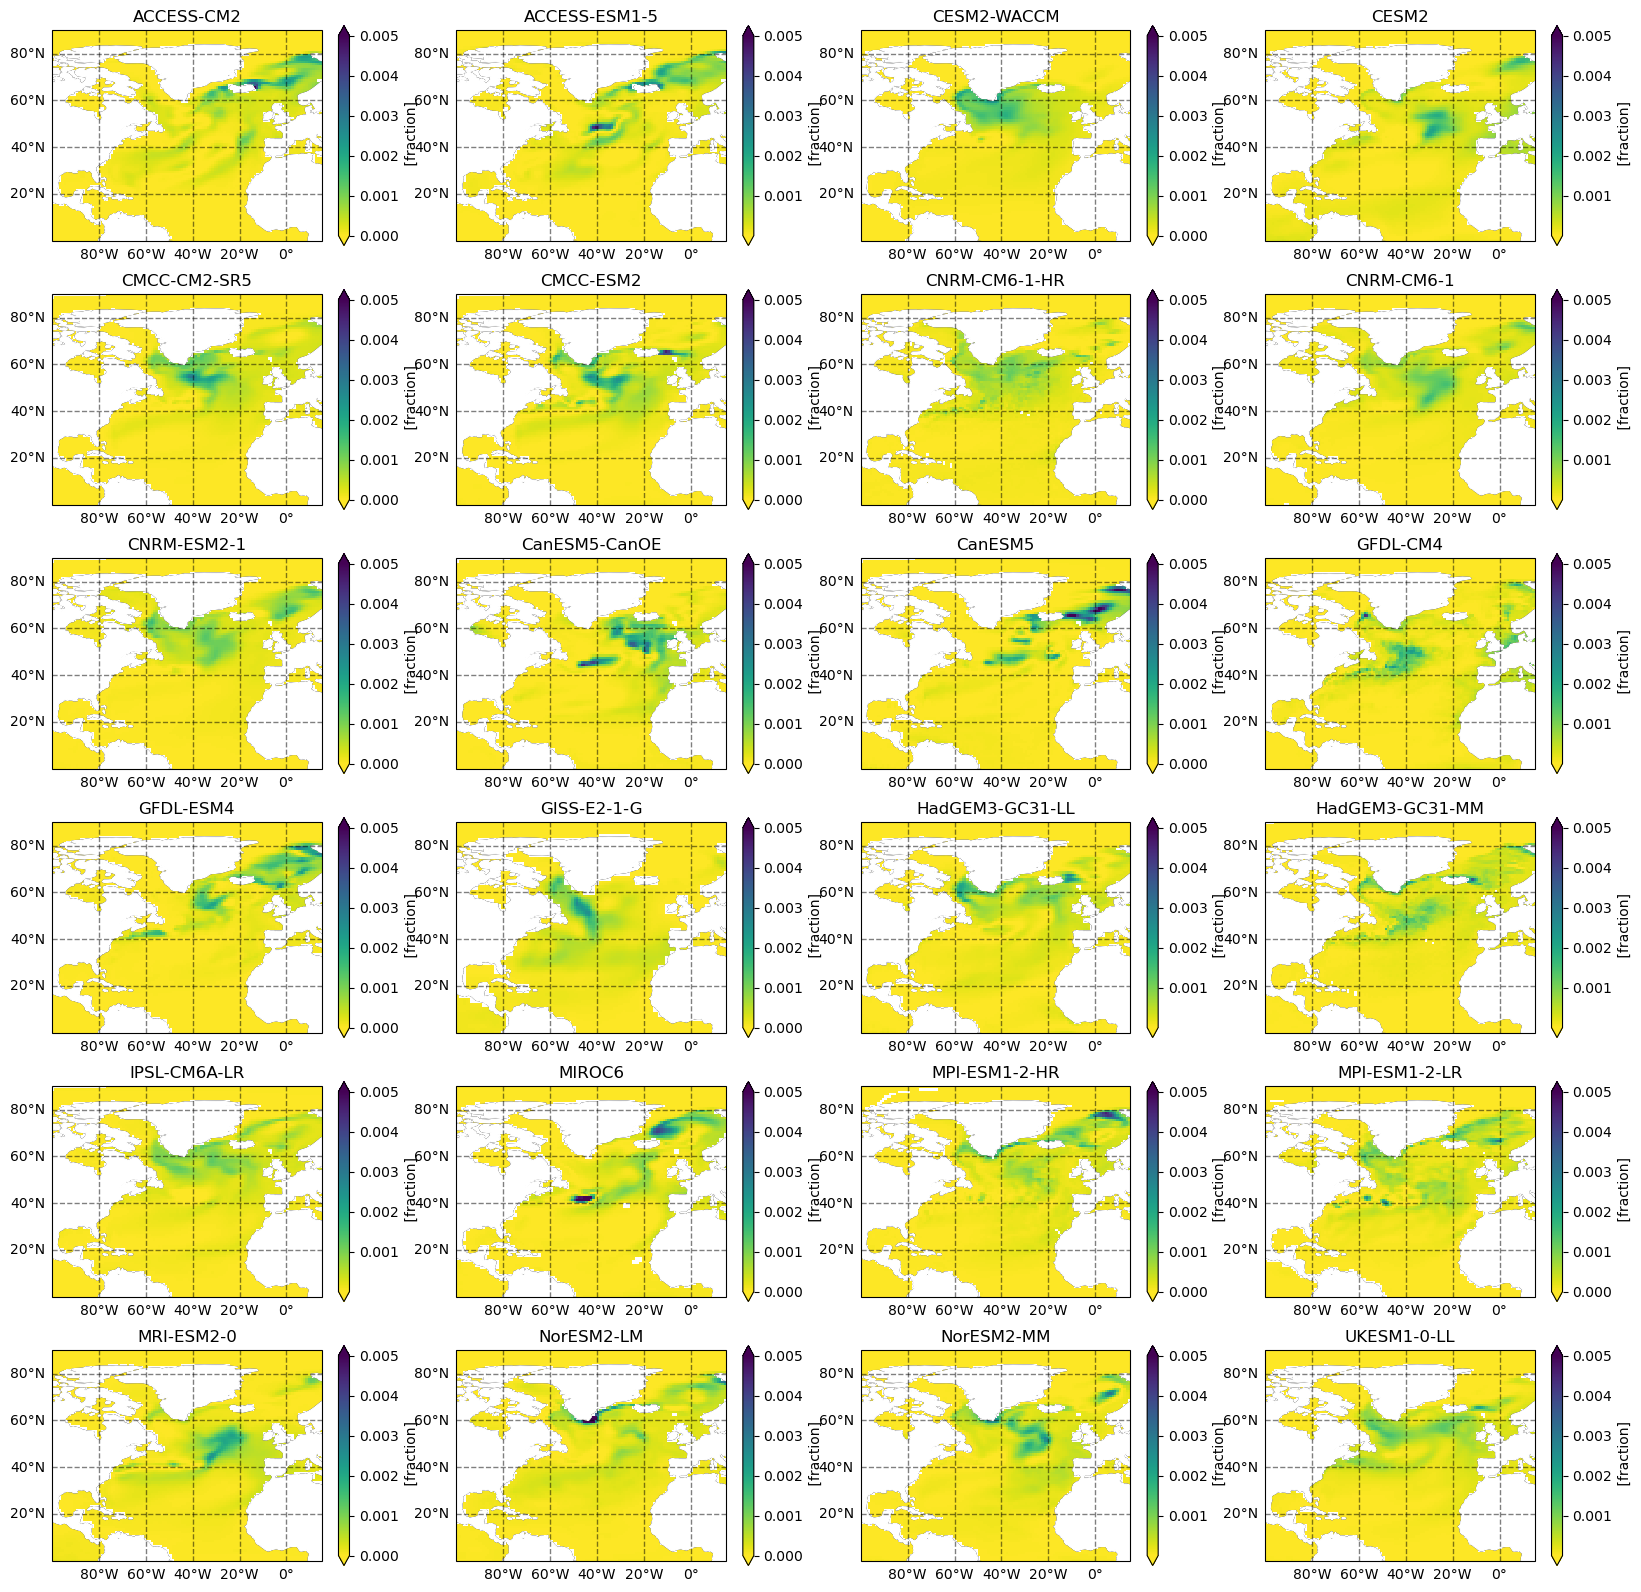

In [4]:
fig, axes = plt.subplots(6, 4, figsize=(20,20), subplot_kw={'projection': ccrs.PlateCarree()}) #, gridspec_kw=gridspec)
axes = axes.ravel()

for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1, len(amoc_smoothed['year'].values)+1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)
    
        # Train regression and reconstruct AMOC
        f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

        # Compute and plot impact maps
        impact = compute_impact_map(f, sst, ny, nx)

        im=impact.plot.pcolormesh(ax=axes[i],  transform=ccrs.PlateCarree(), x='lon', y='lat', extend = 'both', cmap='viridis_r', vmax = 0.005, add_colorbar=True, shading='auto')  


        axes[i].set_title(f"{model}")
        axes[i].coastlines()
        
        land = cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='face',
                                            facecolor='white')
        axes[i].add_feature(land)

        # Define min and max longitude and latitude
        # lon_min, lon_max = -90, 20   # Replace with desired longitude limits
        # lat_min, lat_max = 0, 90    # Replace with desired latitude limits
        
        # Assuming you have a subplot setup with `axes[i]`
        axes[i].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        
        gl = axes[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        # plot = regression_slopes['NorESM2-MM'].plot()
        # plt.show(plot)

plt.show(im)
fig.suptitle("Impact Maps of SST Contribution to AMOC", fontsize=20, y=0.99)  # Title for the whole figure
fig.tight_layout()
# fig.savefig(PATH_plots + "Impact_maps.pdf", bbox_inches="tight")


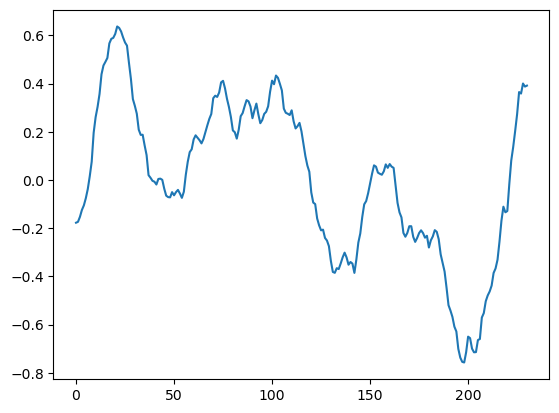

In [5]:
plt.plot(amoc_reconstructed)

In [6]:
np.var(amoc_reconstructed)

0.1084002